In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Cell 2 — Load Data Fixed
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'], usecols=[0,1])
print(df.shape)
print(df['label'].value_counts())
df.head(10)

(5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


/tmp/ipykernel_2169/3685875713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['steelblue', 'tomato'])


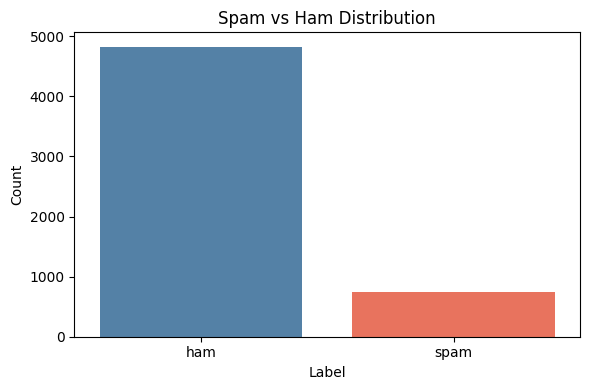

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.482487  58.440652   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.670683  28.873603  13.0  133.0  149.0  157.0  223.0


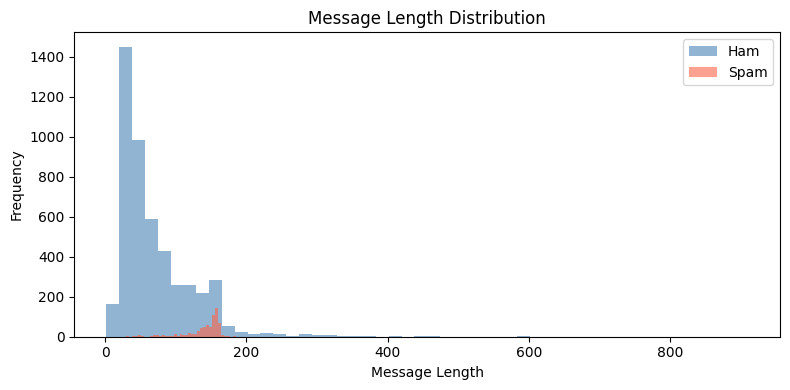

In [4]:
# Cell 3 — EDA
# Class distribution plot
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette=['steelblue', 'tomato'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Message length analysis
df['msg_length'] = df['message'].apply(len)
print(df.groupby('label')['msg_length'].describe())

# Length distribution
plt.figure(figsize=(8,4))
df[df['label']=='ham']['msg_length'].plot(bins=50, kind='hist', alpha=0.6, label='Ham', color='steelblue')
df[df['label']=='spam']['msg_length'].plot(bins=50, kind='hist', alpha=0.6, label='Spam', color='tomato')
plt.legend()
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.tight_layout()
plt.show()

In [5]:
# Cell 4 — Preprocessing
from sklearn.preprocessing import LabelEncoder

# Encode labels: ham=0, spam=1
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])

# Split features and target
X = df['message']
y = df['label_enc']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Spam ratio in test: {y_test.mean():.2%}")

Training samples: 4457
Testing samples: 1115
Spam ratio in test: 13.36%


In [6]:
# Cell 5 — TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
print(f"Training matrix shape: {X_train_tfidf.shape}")


Vocabulary size: 5000
Training matrix shape: (4457, 5000)


In [7]:
# Cell 6 — Train Models
# Model 1: Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Model 2: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print("Both models trained. ✅")

Both models trained. ✅


In [8]:
# Cell 7 — Evaluate Both Models
# Naive Bayes
nb_pred = nb_model.predict(X_test_tfidf)
print("=" * 40)
print("NAIVE BAYES")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(classification_report(y_test, nb_pred, target_names=['Ham', 'Spam']))

# Logistic Regression
lr_pred = lr_model.predict(X_test_tfidf)
print("=" * 40)
print("LOGISTIC REGRESSION")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred, target_names=['Ham', 'Spam']))

NAIVE BAYES
Accuracy: 0.9722
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

LOGISTIC REGRESSION
Accuracy: 0.9704
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



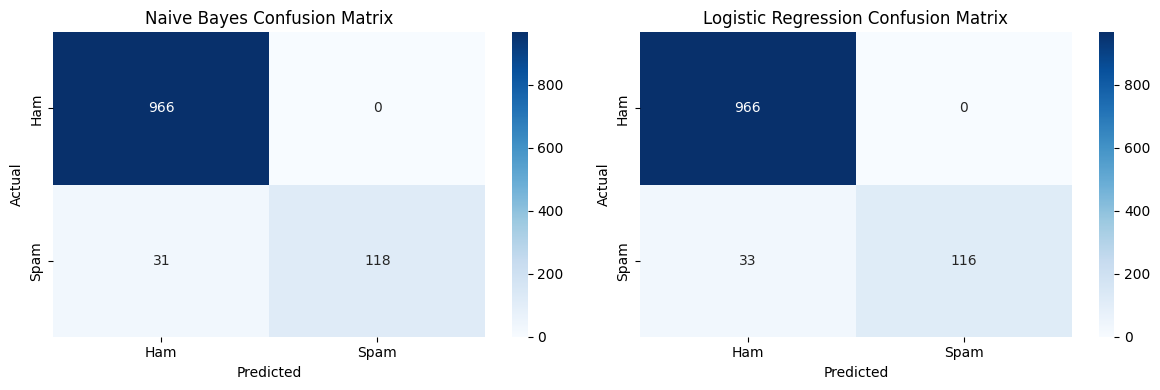

In [9]:
# Cell 8 — Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model_pred, title in zip(axes,
                                  [nb_pred, lr_pred],
                                  ['Naive Bayes', 'Logistic Regression']):
    cm = confusion_matrix(y_test, model_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_title(f'{title} Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [10]:
# Cell 9 — Live Spam Predictor
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = nb_model.predict(message_tfidf)[0]
    probability = nb_model.predict_proba(message_tfidf)[0]

    label = "🚨 SPAM" if prediction == 1 else "✅ HAM"
    confidence = probability[prediction] * 100

    print(f"Message: {message}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")
    print("-" * 50)

# Test it
predict_spam("Congratulations! You've won a FREE iPhone. Click here now to claim your prize!")
predict_spam("Hey, are we still meeting tomorrow for lunch?")
predict_spam("URGENT: Your bank account has been compromised. Call us immediately!")
predict_spam("Can you send me the notes from today's class?")

Message: Congratulations! You've won a FREE iPhone. Click here now to claim your prize!
Prediction: 🚨 SPAM
Confidence: 84.26%
--------------------------------------------------
Message: Hey, are we still meeting tomorrow for lunch?
Prediction: ✅ HAM
Confidence: 99.73%
--------------------------------------------------
Message: URGENT: Your bank account has been compromised. Call us immediately!
Prediction: ✅ HAM
Confidence: 51.67%
--------------------------------------------------
Message: Can you send me the notes from today's class?
Prediction: ✅ HAM
Confidence: 96.72%
--------------------------------------------------


/tmp/ipykernel_2169/2064552226.py:42: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


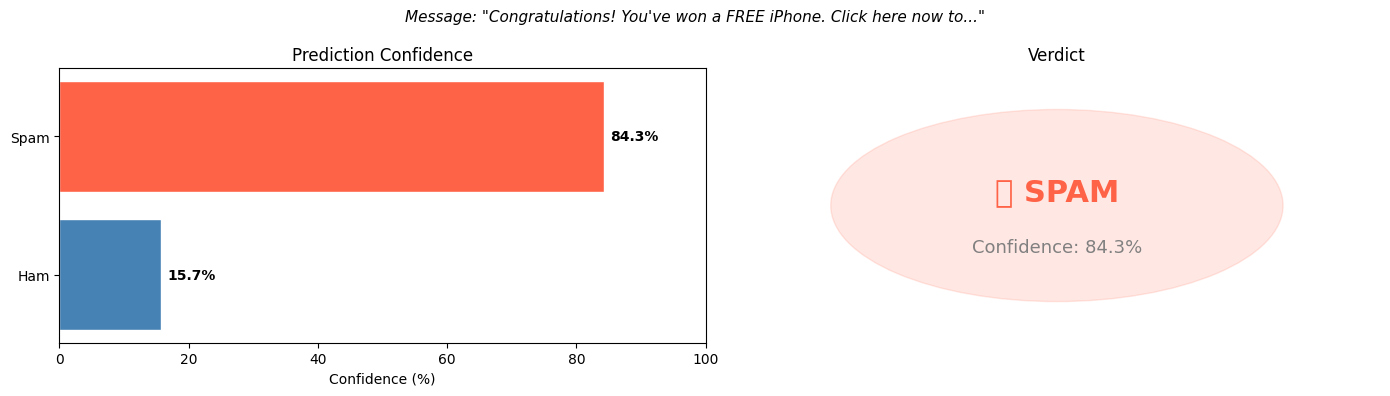

/tmp/ipykernel_2169/2064552226.py:42: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


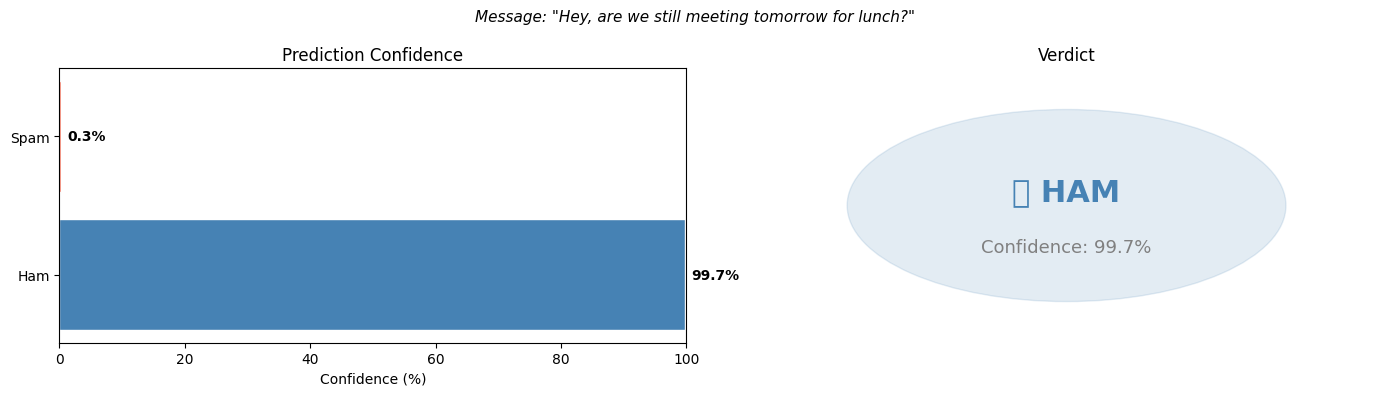

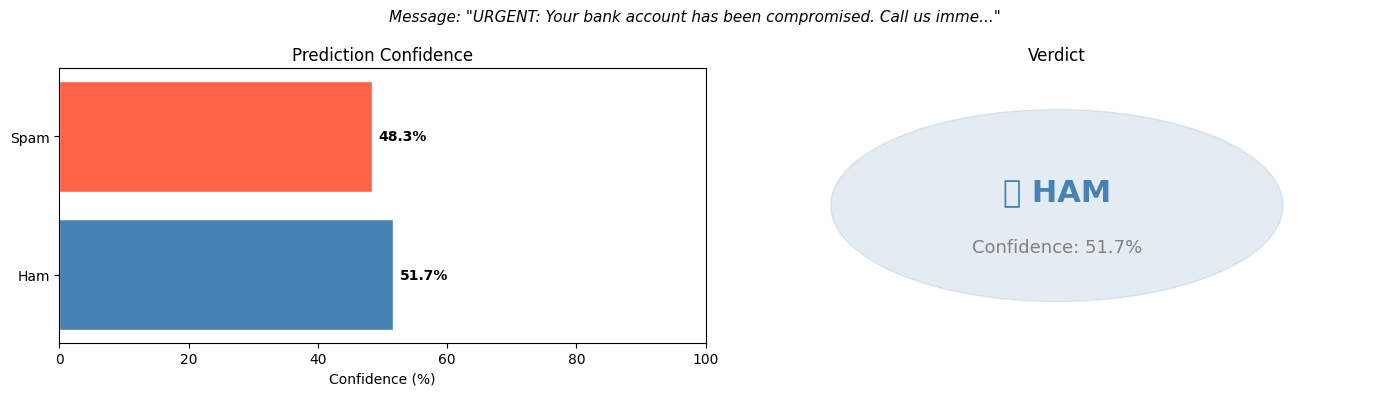

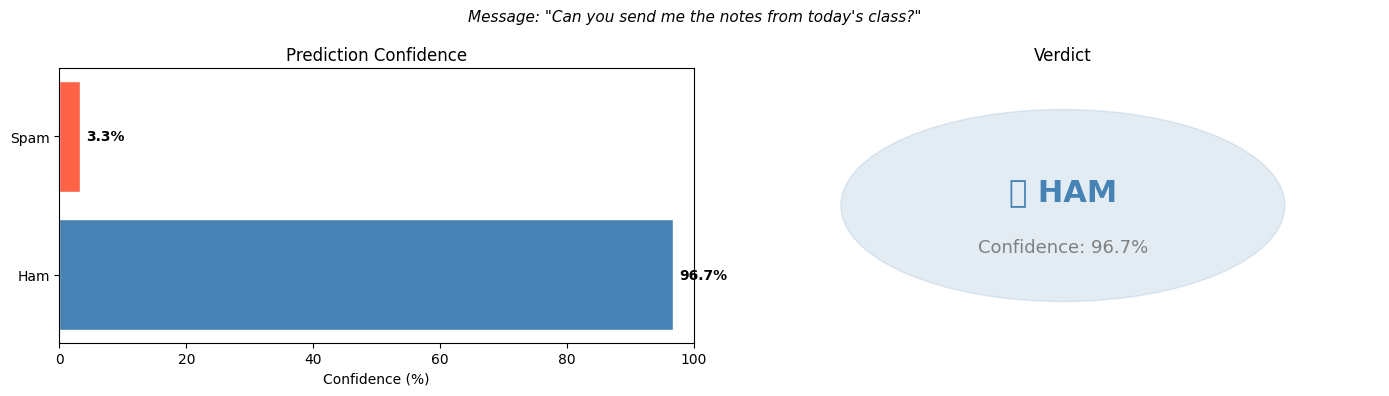

In [12]:
# Cell 10 — Interactive Spam Visualizer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = nb_model.predict(message_tfidf)[0]
    probability = nb_model.predict_proba(message_tfidf)[0]

    spam_prob = probability[1] * 100
    ham_prob = probability[0] * 100
    label = "🚨 SPAM" if prediction == 1 else "✅ HAM"
    color = 'tomato' if prediction == 1 else 'steelblue'

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'Message: "{message[:60]}..."' if len(message) > 60 else f'Message: "{message}"',
                 fontsize=11, style='italic')

    # --- Left: Probability Bar Chart ---
    bars = axes[0].barh(['Ham', 'Spam'], [ham_prob, spam_prob],
                         color=['steelblue', 'tomato'], edgecolor='white')
    axes[0].set_xlim(0, 100)
    axes[0].set_xlabel('Confidence (%)')
    axes[0].set_title('Prediction Confidence')
    for bar, val in zip(bars, [ham_prob, spam_prob]):
        axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontweight='bold')

    # --- Right: Gauge-style verdict ---
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].axis('off')
    circle = plt.Circle((0.5, 0.5), 0.35, color=color, alpha=0.15)
    axes[1].add_patch(circle)
    axes[1].text(0.5, 0.55, label, ha='center', va='center',
                 fontsize=22, fontweight='bold', color=color)
    axes[1].text(0.5, 0.35, f'Confidence: {max(spam_prob, ham_prob):.1f}%',
                 ha='center', va='center', fontsize=13, color='gray')
    axes[1].set_title('Verdict')

    plt.tight_layout()
    plt.show()

# --- Test Messages ---
visualize_spam("Congratulations! You've won a FREE iPhone. Click here now to claim your prize!")
visualize_spam("Hey, are we still meeting tomorrow for lunch?")
visualize_spam("URGENT: Your bank account has been compromised. Call us immediately!")
visualize_spam("Can you send me the notes from today's class?")

In [14]:
# Cell 11 — Install Gradio
!pip install gradio -q

In [18]:
# Cell 12 — Gradio Spam Detector (Colored Highlights) FIXED
import gradio as gr
import re

SPAM_SIGNALS = [
    {'words': ['free'], 'tip': 'Free offers are a top spam trigger', 'weight': 3},
    {'words': ['win', 'won', 'winner'], 'tip': 'Prize claims are classic spam', 'weight': 3},
    {'words': ['congratulations'], 'tip': 'Unsolicited congratulations = red flag', 'weight': 3},
    {'words': ['urgent'], 'tip': 'Urgency tactics pressure victims', 'weight': 3},
    {'words': ['click', 'click here'], 'tip': 'Suspicious call-to-action links', 'weight': 2},
    {'words': ['prize'], 'tip': 'Prize language is a spam staple', 'weight': 3},
    {'words': ['claim'], 'tip': 'Claim your reward = common bait', 'weight': 2},
    {'words': ['cash', 'money'], 'tip': 'Financial incentive language', 'weight': 2},
    {'words': ['limited time'], 'tip': 'Artificial scarcity tactic', 'weight': 2},
    {'words': ['verify', 'verification'], 'tip': 'Phishing often asks to verify details', 'weight': 2},
    {'words': ['bank'], 'tip': 'Bank impersonation is common', 'weight': 2},
    {'words': ['password'], 'tip': 'Legitimate services never ask for passwords', 'weight': 3},
    {'words': ['guaranteed'], 'tip': 'Unrealistic guarantees = red flag', 'weight': 2},
    {'words': ['call us', 'call now'], 'tip': 'Pressure to call immediately', 'weight': 2},
    {'words': ['compromised'], 'tip': 'Fear-inducing security language', 'weight': 3},
    {'words': ['100%'], 'tip': 'Unrealistic percentage claims', 'weight': 2},
    {'words': ['apply now'], 'tip': 'Unsolicited application pressure', 'weight': 2},
]

def analyze(message):
    if not message.strip():
        return "", "", "", ""

    lower_msg = message.lower()
    spam_score = 0
    max_score = sum(s['weight'] for s in SPAM_SIGNALS)
    found_tips = []
    highlights = []

    for sig in SPAM_SIGNALS:
        matched = False
        for w in sig['words']:
            for m in re.finditer(re.escape(w), lower_msg):
                highlights.append((m.start(), m.end(), sig['tip']))
            if w.lower() in lower_msg:
                matched = True
        if matched:
            spam_score += sig['weight']
            if sig['tip'] not in found_tips:
                found_tips.append(sig['tip'])

    highlights.sort(key=lambda x: x[0])
    clean = []
    for h in highlights:
        if not clean or h[0] >= clean[-1][1]:
            clean.append(h)

    html_out = ""
    prev = 0
    for start, end, tip in clean:
        html_out += re.sub(r'\n', '<br>', message[prev:start])
        html_out += f'<mark style="background:#F7C1C1;color:#791F1F;border-radius:3px;padding:1px 4px;font-weight:600;" title="{tip}">{message[start:end]}</mark>'
        prev = end
    html_out += re.sub(r'\n', '<br>', message[prev:])

    highlighted_html = f'<div style="font-size:14px;line-height:2;font-family:Arial,sans-serif;">{html_out}</div>'

    if found_tips:
        reasons_out = "\n".join([f"• {t}" for t in found_tips[:4]])
    else:
        reasons_out = "• No strong spam signals detected"

    spam_prob = min(0.97, max(0.03, spam_score / max(max_score * 0.35, 1)))
    is_spam = spam_prob > 0.45
    spam_pct = round(spam_prob * 100)
    ham_pct = 100 - spam_pct
    confidence_out = f"Ham:  {ham_pct}%  {'█' * (ham_pct // 5)}{'░' * (20 - ham_pct // 5)}\nSpam: {spam_pct}%  {'█' * (spam_pct // 5)}{'░' * (20 - spam_pct // 5)}"

    if is_spam:
        verdict_out = f"🚨 SPAM DETECTED\nConfidence: {spam_pct}% — Treat with caution."
    else:
        verdict_out = f"✅ LOOKS SAFE\nConfidence: {ham_pct}% — No major spam signals found."

    return highlighted_html, reasons_out, confidence_out, verdict_out

demo = gr.Interface(
    fn=analyze,
    inputs=gr.Textbox(lines=5, placeholder="Paste your email or SMS message here...", label="Input Message"),
    outputs=[
        gr.HTML(label="Highlighted Triggers"),
        gr.Textbox(label="Why It's Flagged", lines=5),
        gr.Textbox(label="Confidence", lines=3),
        gr.Textbox(label="Final Verdict", lines=3),
    ],
    title="Spam Detector",
    description="Paste any message to detect spam triggers, reasons, confidence, and final verdict.",
    examples=[
        ["Congratulations! You've won a FREE iPhone. Click here NOW to claim your prize!"],
        ["URGENT: Your bank account has been compromised. Call us immediately!"],
        ["Hey, are we still meeting tomorrow for lunch?"],
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c8289f07b9fa269512.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
